In [1]:
import numpy as np
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [11]:
def extract_his_2d(vars,ilats,ilons,fn_his):
    data_out = dict()
    nlt = len(ilats)
    time_0 = datetime(1999,1,1)
  
    with nc.Dataset(fn_his) as ds:
        t1 = ds.variables['ocean_time'][:]
        data_out['ocean_time'] = time_0 + t1.data[:] * timedelta(seconds=1)
        nt = len(t1)
        for var in vars:
            his2d = np.zeros((nt,nlt))
            for ii in np.arange(nlt):
                his2d[:,ii] = ds.variables[var][:,ilats[ii],ilons[ii]].data
            
            data_out[var] = his2d
 
    return data_out

def dlat_to_dy(dlat,alat):
#
# dy   = latitude difference in meters
# dlat = latidute difference in degrees
# alat = average latitude between the two fixes
# Reference: American Practical Navigator, Vol II, 1975 Edition, p 5

    rlat = alat * np.pi/180
    m = (111132.09 * rlat - 
        566.05 * np.cos(2 * rlat) + 1.2 * np.cos(4 * rlat) )
    dy = m * dlat
    return dy

def dlon_to_dx(dlon,alat):
#
# dlon = longitude difference in degrees
# dx   = longitude difference in meters
# alat = average latitude between the two fixes

    rlat = alat * np.pi/180
    p = 111415.13 * np.cos(rlat) - 94.55 * np.cos(3 * rlat)
    dx = p * dlon 
    return dx


def get_lat_lon_indices(lats,lons,lvl):
    if lvl == 'LV1':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV1_rx020_hmask.nc'
    elif lvl == 'LV2':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV2_rx020.nc'
    elif lvl == 'LV3':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV3_rx020.nc'
    elif lvl == 'LV4':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV4_mss_oct2024.nc'

    with nc.Dataset(fn_grd) as ds:
        latg = ds.variables['lat_rho'][:]
        long = ds.variables['lon_rho'][:]
        mask_rho = ds.variables['mask_rho'][:]

    bar_lat = np.mean(latg)
    bar_lon = np.mean(long)
    xg = dlon_to_dx(long-bar_lon,bar_lat)
    yg = dlat_to_dy(latg-bar_lat,bar_lat)

    x0 = dlon_to_dx(lons-bar_lon,bar_lat)
    y0 = dlat_to_dy(lats-bar_lat,bar_lat)    

    cnt = 0
    ilt = []
    iln = []
    for y in y0:
        x = x0[cnt]
        dy = yg-y
        dx = xg-x
        D2 = np.square(dx) + np.square(dy)
        # Find the flattened index of the minimum value
        min_flat_index = np.argmin(D2)

        # Convert the flattened index to (row, column) indices
        row_index, col_index = np.unravel_index(min_flat_index, D2.shape)
        
        # check and see if mask_rho is 1 (ocean) here...
        land = True
        while land:
            msk = mask_rho[row_index,col_index]
            if msk == 1:
                land = False
                print('the (lat,lon) requested was: ',lats[cnt],',',lons[cnt])
                print('the (lat,lon) found is: ',latg[row_index,col_index],',',long[row_index,col_index])
            else:
                # move offshore and south!
                print('the lat,lon requested is land. moving offshore and south by 1')
                row_index = row_index - 1
                col_index = col_index - 1

        ilt.append(row_index)
        iln.append(col_index)

        cnt += 1    


    return ilt,iln

In [4]:

lats = [32.50,32.55]
lons = [-117.2,-117.2]
var = 'zeta'
t1 = '20241011' # start time of first file
t2 = '20241020' # start time of last file



In [5]:
ilt3,iln3 = get_lat_lon_indices(lats,lons,'LV3')
print(ilt3,iln3)


the (lat,lon) requested was:  32.5 , -117.2
the (lat,lon) found is:  32.49941668873491 , -117.20084239467755
the (lat,lon) requested was:  32.55 , -117.2
the (lat,lon) found is:  32.550168363402186 , -117.20043268156094
[np.int64(121), np.int64(146)] [np.int64(165), np.int64(176)]


In [ ]:

fn_his = '/scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410110000.nc'
data = extract_his_2d(['zeta'],ilt3,iln3,fn_his)


t = data['ocean_time'][:]
zeta = data['zeta'][:]
print(np.shape(zeta))

fig, ax = plt.subplots()
ax.plot(t,zeta)



In [ ]:
fn = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202509240600.nc'
fn_gr = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'
with nc.Dataset(fn) as ds:
    s_w = ds.variables['s_w'][:].data
    Cs_w = ds.variables['Cs_w'][:].data
    zeta = ds.variables['zeta'][:].data
    pn = ds.variables['pn'][:].data
    pm = ds.variables['pm'][:].data
    time = ds.variables['ocean_time'][:].data
    print(ds)

with nc.Dataset(fn_gr) as ds_gr:
    hb = ds_gr.variables['h'][:].data


In [ ]:
zeta_1 = np.squeeze( zeta[0,:,:] )
z_w = zeta_1 + (zeta_1 + hb) * Cs_w[:,np.newaxis,np.newaxis]
Hz = np.diff(z_w,axis=0)
Area = 1/(pn*pm + 1e-10)
Volume = Hz * Area 



print(np.shape(z_w))
print(np.shape(Hz))
print(np.shape(Area))
print(np.shape(Volume))
print(np.cbrt( Volume[0,0:10,0:10] ))
print(np.sqrt( Area[0:10,0:10]))

fig, ax = plt.subplots()
im = ax.imshow(np.sqrt( Area) )
plt.colorbar(im, ax=ax, location='bottom', pad=0.1) # pad adjusts distance from image



In [6]:
def get_dye_volumes(fn_his,fn_grd):

    with nc.Dataset(fn_grd) as ds_gr:
        hb = ds_gr.variables['h'][:].data

    with nc.Dataset(fn_his) as ds:
        s_w = ds.variables['s_w'][:].data
        Cs_w = ds.variables['Cs_w'][:].data
        pn = ds.variables['pn'][:].data
        pm = ds.variables['pm'][:].data
        Area = 1/(pn*pm + 1e-10)
        time = ds.variables['ocean_time'][:].data
        time_0 = datetime(1999,1,1)
        t = time_0 + time * timedelta(seconds=1)
        nt = len(time)
        V_dye1 = np.zeros(nt)
        V_dye2 = np.zeros(nt)
        V_tot = np.zeros(nt)
        for ii in np.arange(nt):
            dye1 = ds.variables['dye_01'][ii,:,:,:].data
            dye2 = ds.variables['dye_02'][ii,:,:,:].data
            zeta = ds.variables['zeta'][ii,:,:].data
            msk  = ds.variables['wetdry_mask_rho'][ii,:,:].data 
            z_w = zeta + (zeta + hb) * Cs_w[:,np.newaxis,np.newaxis]
            Hz = np.diff(z_w,axis=0)
            Volume = Hz * Area
            Vd1 = dye1 * Volume
            Vd2 = dye2 * Volume
            Vd1z = np.sum(Vd1,axis=0) # sum in vertical
            Vd2z = np.sum(Vd2,axis=0)
            Vd1z = Vd1z * msk # zero out land
            Vd2z = Vd2z * msk
            V_tot[ii] = np.sum( msk * np.sum(Volume,axis=0) )
            V_dye1[ii] = np.sum(Vd1z)
            V_dye2[ii] = np.sum(Vd2z) 

    return t, V_dye1, V_dye2, V_tot

In [ ]:
fn_his = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202509240600.nc'
fn_grd = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'
t, V_dye1, V_dye2, V_tot = get_dye_volumes(fn_his,fn_grd)



In [7]:
fn_grd = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'
dir0 = '/scratch/PHM_Simulations/LV4_Forecast/His/'
fn = 'LV4_ocean_his_'
date_1 = datetime(2024,10,11)
date_2 = datetime(2024,10,20)
date_list_txt = []
date = date_1
while date <= date_2:
    date_list_txt.append(date.strftime('%Y%m%d'))
    date = date + timedelta(days=1)

file_list = []
for dtxt in date_list_txt:
    file_list.append(dir0+fn+dtxt+'0000.nc')

cnt = 0
for file in file_list:
    t0 = datetime.now()
    print('getting dye volumes in ', file)
    t, V_dye1, V_dye2, V_tot = get_dye_volumes(file,fn_grd)
    if cnt==0:
        t2 = t
        Vd1 = V_dye1
        Vd2 = V_dye2
    else:
        t2 = np.append(t2,t[1:])
        Vd1 = np.append(Vd1,V_dye1[1:])
        Vd2 = np.append(Vd2,V_dye2[1:])
    print('...done. This took:')
    print(datetime.now()-t0)
    cnt += 1

getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410110000.nc
...done. This took:
0:00:02.499619
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410120000.nc
...done. This took:
0:00:02.446127
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410130000.nc
...done. This took:
0:00:02.440788
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410140000.nc
...done. This took:
0:00:02.459633
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410150000.nc
...done. This took:
0:00:02.414050
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410160000.nc
...done. This took:
0:00:02.472256
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410170000.nc
...done. This took:
0:00:02.452004
getting dye volumes in  /scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202

(array([20007., 20009., 20011., 20013., 20015., 20017.]),
 [Text(20007.0, 0, '2024-10-11'),
  Text(20009.0, 0, '2024-10-13'),
  Text(20011.0, 0, '2024-10-15'),
  Text(20013.0, 0, '2024-10-17'),
  Text(20015.0, 0, '2024-10-19'),
  Text(20017.0, 0, '2024-10-21')])

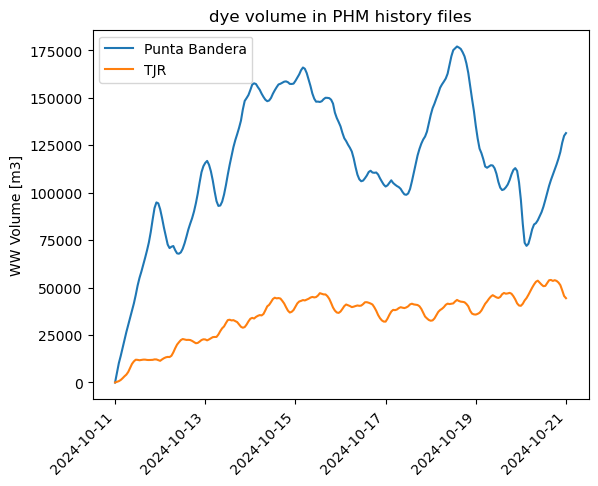

In [ ]:
fig, ax = plt.subplots()
ax.plot(t2,Vd1,label='Punta Bandera')
ax.plot(t2,Vd2,label='TJR')
plt.legend()
plt.ylabel('WW Volume [m3]')
plt.title('dye volume in PHM history files')
plt.xticks(rotation=45, ha='right')



<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    history: Created by create_roms_tide_forc on 05-Jun-2018 16:09:50
    type: tide forcing file
    dimensions(sizes): xrho(253), erho(390), tide_period(10)
    variables(dimensions): float64 tide_period(tide_period), float64 tide_Ephase(tide_period, erho, xrho), float64 tide_Eamp(tide_period, erho, xrho), float64 tide_Cphase(tide_period, erho, xrho), float64 tide_Cangle(tide_period, erho, xrho), float64 tide_Cmin(tide_period, erho, xrho), float64 tide_Cmax(tide_period, erho, xrho)
    groups: 
<class 'netCDF4.Variable'>
float64 tide_Eamp(tide_period, erho, xrho)
    long_name: tidal elevation amplitude
    units: meter
    field: tide_Eamp, scalar, series
unlimited dimensions: 
current shape = (10, 390, 253)
filling on, default _FillValue of 9.969209968386869e+36 used
[2.64307223e-01 1.51879750e-01 9.45190964e-02 2.72370905e-02
 4.01747242e-01 1.77814543e-01 9.80797348e-02 3.76291154e-02
 1.95936

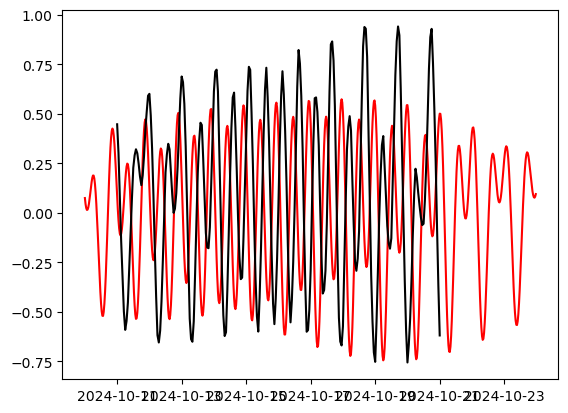

In [43]:
fig, ax = plt.subplots()

fn_tide = '/scratch/PFM_Simulations/tide_data/roms_tide_adcirc_LV01.nc'
dst = nc.Dataset(fn_tide)
print(dst)
print(dst.variables['tide_Eamp'])
print(dst.variables['tide_Eamp'][:,0,0])
print(dst.variables['tide_period'])
print(dst.variables['tide_period'][:])
print(dst.variables['tide_Ephase'])

t_ref = datetime(1999,1,1)
t_tide_ref = t_ref + 6025 * timedelta(days=1)
t1 = datetime(2024,10,10)
tt = t1-t_tide_ref 
# time_tide is hours past t_tide_ref...
time_tide = np.arange( tt.total_seconds()/3600, tt.total_seconds()/3600 + 14*24, 0.5)
t_dt = t_tide_ref + time_tide * timedelta(hours=1)
print(t_tide_ref)
print(t_dt[0])

eta = 0 * time_tide
Amps = dst.variables['tide_Eamp'][:,0,0].data
cnt = 0
for Amp in Amps:
    phi = dst.variables['tide_Ephase'][cnt,0,0].data
    Tp  = dst.variables['tide_period'][cnt].data
    eta1 =  Amp * np.sin( 2*np.pi/Tp*time_tide + np.pi/180*phi)
    eta = eta+eta1
    cnt += 1

ax.plot(t_dt,eta,'r')


lvs = ['1']
std_zeta = []

for lv in lvs:
    ilt3,iln3 = get_lat_lon_indices([28.52086256],[-120.26323203],'LV'+lv)
    dir0 = '/scratch/PHM_Simulations/LV'+lv+'_Forecast/His/LV'+lv+'_ocean_his_'    
    date_1 = datetime(2024,10,11)
    date_2 = datetime(2024,10,20)
    date_list_txt = []
    date = date_1
    while date <= date_2:
        date_list_txt.append(date.strftime('%Y%m%d'))
        date = date + timedelta(days=1)

    file_list = []
    for dtxt in date_list_txt:
        file_list.append(dir0+dtxt+'0000.nc')

    cnt = 0
    for file in file_list:
        t0 = datetime.now()
        print('getting data in ', file)
        data = extract_his_2d(['zeta'],ilt3,iln3,file)
        if cnt==0:
            t = data['ocean_time'][:]
            zeta = data['zeta'][:,0]
        else:
            t = np.append(t,data['ocean_time'][:])
            zeta = np.append(zeta,data['zeta'][:,0])
        print('...done. This took:')
        print(datetime.now()-t0)
        cnt += 1

    stdz = np.std(zeta)
    std_zeta.append(stdz)

    ax.plot(t,zeta,'k')

print(std_zeta)

the (lat,lon) requested was:  32.5 , -117.2
the (lat,lon) found is:  32.50771530218736 , -117.20029432421403
the (lat,lon) requested was:  32.55 , -117.2
the (lat,lon) found is:  32.54505110052812 , -117.19781287118445
getting data in  /scratch/PHM_Simulations/LV1_Forecast/His/LV1_ocean_his_202410110000.nc
...done. This took:
0:00:00.008045
getting data in  /scratch/PHM_Simulations/LV1_Forecast/His/LV1_ocean_his_202410120000.nc
...done. This took:
0:00:00.005756
getting data in  /scratch/PHM_Simulations/LV1_Forecast/His/LV1_ocean_his_202410130000.nc
...done. This took:
0:00:00.005639
getting data in  /scratch/PHM_Simulations/LV1_Forecast/His/LV1_ocean_his_202410140000.nc
...done. This took:
0:00:00.005718
getting data in  /scratch/PHM_Simulations/LV1_Forecast/His/LV1_ocean_his_202410150000.nc
...done. This took:
0:00:00.005587
getting data in  /scratch/PHM_Simulations/LV1_Forecast/His/LV1_ocean_his_202410160000.nc
...done. This took:
0:00:00.005560
getting data in  /scratch/PHM_Simulat

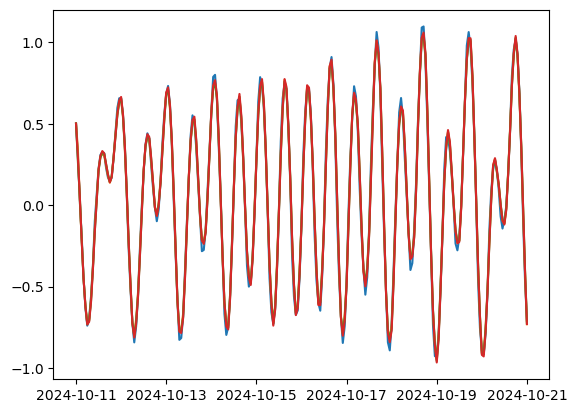

In [21]:
fig, ax = plt.subplots()

lvs = ['1','2','3','4']
std_zeta = []

for lv in lvs:
    ilt3,iln3 = get_lat_lon_indices(lats,lons,'LV'+lv)
    dir0 = '/scratch/PHM_Simulations/LV'+lv+'_Forecast/His/LV'+lv+'_ocean_his_'    
    date_1 = datetime(2024,10,11)
    date_2 = datetime(2024,10,20)
    date_list_txt = []
    date = date_1
    while date <= date_2:
        date_list_txt.append(date.strftime('%Y%m%d'))
        date = date + timedelta(days=1)

    file_list = []
    for dtxt in date_list_txt:
        file_list.append(dir0+dtxt+'0000.nc')

    cnt = 0
    for file in file_list:
        t0 = datetime.now()
        print('getting data in ', file)
        data = extract_his_2d(['zeta'],ilt3,iln3,file)
        if cnt==0:
            t = data['ocean_time'][:]
            zeta = data['zeta'][:,0]
        else:
            t = np.append(t,data['ocean_time'][:])
            zeta = np.append(zeta,data['zeta'][:,0])
        print('...done. This took:')
        print(datetime.now()-t0)
        cnt += 1

    stdz = np.std(zeta)
    std_zeta.append(stdz)

    ax.plot(t,zeta)

print(std_zeta)


In [ ]:

fig, ax = plt.subplots()
ax.plot(t,V_dye1,label='Punta Bandera')
ax.plot(t,V_dye2,label='TJR')
plt.legend()
plt.ylabel('WW Volume [m3]')



In [17]:
fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV1_rx020_hmask.nc'
dsg = nc.Dataset(fn_grd)
print(dsg)
lat = dsg.variables['lat_rho'][:].data
lon = dsg.variables['lon_rho'][:].data

print(lat[0:3,0:3])
print(lon[0:3,0:3])

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    type: ROMS GRID file
    gridid: theGridTitle
    history: Created by create_roms_netcdf_grid_file, on 28-May-2018 10:21:21
    title: ROMS Application
    dimensions(sizes): xi_psi(252), xi_rho(253), xi_u(252), xi_v(253), eta_psi(389), eta_rho(390), eta_u(390), eta_v(389), one(1), two(2), bath(1)
    variables(dimensions): float64 xl(one), float64 el(one), |S1 JPRJ(two), |S1 spherical(one), int16 depthmin(one), int16 depthmax(one), float64 hraw(bath, eta_rho, xi_rho), float64 h(eta_rho, xi_rho), float64 f(eta_rho, xi_rho), float64 pm(eta_rho, xi_rho), float64 pn(eta_rho, xi_rho), float64 dndx(eta_rho, xi_rho), float64 dmde(eta_rho, xi_rho), float64 x_rho(eta_rho, xi_rho), float64 y_rho(eta_rho, xi_rho), float64 x_psi(eta_psi, xi_psi), float64 y_psi(eta_psi, xi_psi), float64 x_u(eta_u, xi_u), float64 y_u(eta_u, xi_u), float64 x_v(eta_v, xi_v), float64 y_v(eta_v, xi_v), float64 lat_rho(eta_rho, x

In [ ]:


time_0 = datetime(1999,1,1)
t2 = time_0 + time * timedelta(seconds=1)
print(t2)

In [ ]:

Hz = np.diff(z_w)

s_w = ds.variables['s_w'][:].data
Cs_w = ds.variables['Cs_w'][:].data
zeta = ds.variables['zeta'][:].data
hb = ds_gr.variables['h'][:].data


In [ ]:


dum = np.random.rand(7,6)
dum2 = dum[:,[2,4,5]]
print(dum2)


<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    history: Created by create_roms_tide_forc on 05-Jun-2018 16:09:50
    type: tide forcing file
    dimensions(sizes): xrho(253), erho(390), tide_period(10)
    variables(dimensions): float64 tide_period(tide_period), float64 tide_Ephase(tide_period, erho, xrho), float64 tide_Eamp(tide_period, erho, xrho), float64 tide_Cphase(tide_period, erho, xrho), float64 tide_Cangle(tide_period, erho, xrho), float64 tide_Cmin(tide_period, erho, xrho), float64 tide_Cmax(tide_period, erho, xrho)
    groups: 
<class 'netCDF4.Variable'>
float64 tide_Eamp(tide_period, erho, xrho)
    long_name: tidal elevation amplitude
    units: meter
    field: tide_Eamp, scalar, series
unlimited dimensions: 
current shape = (10, 390, 253)
filling on, default _FillValue of 9.969209968386869e+36 used
[2.64307223e-01 1.51879750e-01 9.45190964e-02 2.72370905e-02
 4.01747242e-01 1.77814543e-01 9.80797348e-02 3.76291154e-02
 1.95936

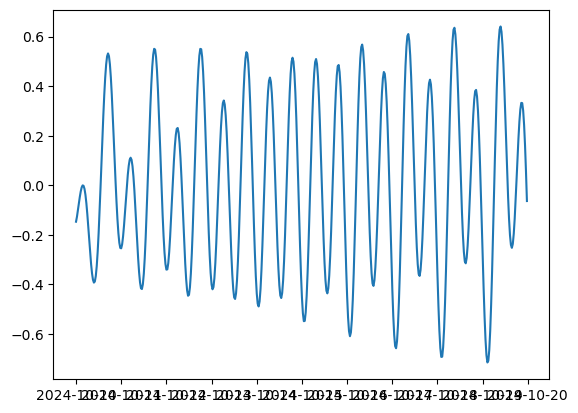

In [12]:
import glob
import os
import subprocess

def find_files_matching_patterns(directory, patterns):
    """
    Finds all files in a given directory (and its subdirectories)
    that match any of the provided patterns.

    Args:
        directory (str): The path to the directory to search.
        patterns (list): A list of strings, where each string is a
                         shell-style wildcard pattern (e.g., "*.txt", "image_*.png").

    Returns:
        list: A list of full file paths that match any of the patterns.
    """
    matching_files = []
    for pattern in patterns:
        # Construct the full pattern path for glob, including the directory
        full_pattern_path = os.path.join(directory, "**", pattern)
        # Use glob.glob with recursive=True to search subdirectories
        found_files = glob.glob(full_pattern_path, recursive=True)
        matching_files.extend(found_files)
    
    # Remove duplicates in case a file matches multiple patterns
    return list(set(matching_files))


In [ ]:

dir0 = '/scratch/PHM_Simulations'
dir_roots = ['/riv_nwm','/riv_ibwc_raw','/riv_vpfm']
dir_l2 = ['/river_data','/cdip_data','/hycom_data','/restart_data','/LV1_Forecast','/LV2_Forecast','/LV3_Forecast','/LV4_Forecast']
dir_l3 = ['/Forc','/Run','/Plot','/His']
search_patterns = ['*.yaml','*.h','*.dat']

for d1 in dir_roots:
    cmd_l = ['mkdir',dir0+d1]
    subprocess.run(cmd_l)
    for d2 in dir_l2:
        cmd_ll = ['mkdir',dir0+d1+d2]
        subprocess.run(cmd_ll)
        for d3 in dir_l3:
            dd = dir0 + d1 + d2 + d3
            print('make directory', dd)
            cmd_l1 = ['mkdir',dd]
            subprocess.run(cmd_l1)
            if d3 == '/Run' and d2[-4:] == 'cast': 
                d_og = dir0 + d2
                found_files = find_files_matching_patterns(d_og, search_patterns)
                for file in found_files:
                    print('copy ', file, ' to ',dd)
                    cmd_l2 = ['cp',file,dd]
                    subprocess.run(cmd_l2)
                
                


make directory /scratch/PHM_Simulations/riv_nwm/river_data/Forc
make directory /scratch/PHM_Simulations/riv_nwm/river_data/Run
make directory /scratch/PHM_Simulations/riv_nwm/river_data/Plot
make directory /scratch/PHM_Simulations/riv_nwm/river_data/His
make directory /scratch/PHM_Simulations/riv_nwm/cdip_data/Forc
make directory /scratch/PHM_Simulations/riv_nwm/cdip_data/Run
make directory /scratch/PHM_Simulations/riv_nwm/cdip_data/Plot
make directory /scratch/PHM_Simulations/riv_nwm/cdip_data/His
make directory /scratch/PHM_Simulations/riv_nwm/hycom_data/Forc
make directory /scratch/PHM_Simulations/riv_nwm/hycom_data/Run
make directory /scratch/PHM_Simulations/riv_nwm/hycom_data/Plot
make directory /scratch/PHM_Simulations/riv_nwm/hycom_data/His
make directory /scratch/PHM_Simulations/riv_nwm/restart_data/Forc
make directory /scratch/PHM_Simulations/riv_nwm/restart_data/Run
make directory /scratch/PHM_Simulations/riv_nwm/restart_data/Plot
make directory /scratch/PHM_Simulations/riv_n

: 